# Notebook de EDA + Limpeza de dados de Vendas (2023/2024)

## Configuração de Ambiente


### Bibliotecas python

In [128]:
import pandas as pd
import numpy as np
import json
from pathlib import Path

### Caminho base do projeto

In [129]:
BASE_PATH = Path().resolve()

while BASE_PATH.name != "lh-nautical-data-project":
    BASE_PATH = BASE_PATH.parent

print(f"BASE PATH: {BASE_PATH}")

BASE PATH: /Users/richardgomes/lh-nautical-data-project


### Caminhos para os dados raw e staging

In [130]:
DATA_PATH = BASE_PATH / "data"
RAW_PATH = DATA_PATH / "raw"
STAGING_PATH = DATA_PATH / "staging"

In [131]:
print(f"RAW PATH: {RAW_PATH}")
print(f"STAGING PATH: {STAGING_PATH}")

RAW PATH: /Users/richardgomes/lh-nautical-data-project/data/raw
STAGING PATH: /Users/richardgomes/lh-nautical-data-project/data/staging


#### Leitura e carregamento dos dados de vendas (vendas_2023_2024.csv)

In [132]:
df_vendas = pd.read_csv(RAW_PATH / "vendas_2023_2024.csv", encoding="utf-8")

In [133]:
df_vendas.shape

(9895, 6)

In [134]:
df_vendas.head(10)

,id,id_client,id_product,qtd,total,sale_date
0,0,42,105,11,3405.00,2023-09-10
1,1,3,136,9,16873.90,15-09-2024
2,2,25,139,7,9475.30,2024-08-13
3,4,20,23,5,55893.00,2023-02-03
4,5,8,57,4,451403.90,2024-02-12
5,6,36,52,3,39056.40,2023-09-26
6,8,27,25,3,34560.05,2024-02-28
7,9,37,26,7,114932.90,07-11-2023
8,10,31,143,3,12643.55,2024-08-25
9,11,39,128,5,23254.00,2023-05-07


In [135]:
df_vendas.info()
df_vendas["sale_date"].head(10)

<class 'pandas.DataFrame'>
RangeIndex: 9895 entries, 0 to 9894
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          9895 non-null   int64  
 1   id_client   9895 non-null   int64  
 2   id_product  9895 non-null   int64  
 3   qtd         9895 non-null   int64  
 4   total       9895 non-null   float64
 5   sale_date   9895 non-null   str    
dtypes: float64(1), int64(4), str(1)
memory usage: 464.0 KB


0    2023-09-10
1    15-09-2024
2    2024-08-13
3    2023-02-03
4    2024-02-12
5    2023-09-26
6    2024-02-28
7    07-11-2023
8    2024-08-25
9    2023-05-07
Name: sale_date, dtype: str

Padronização da coluna de datas (sale_date)

In [136]:
df_vendas["data_venda"] = pd.to_datetime(
    df_vendas["sale_date"],
    dayfirst=True,
    errors="coerce"
)

df_vendas[["sale_date", "data_venda"]].head(10)

,sale_date,data_venda
0,2023-09-10,2023-10-09
1,15-09-2024,NaT
2,2024-08-13,NaT
3,2023-02-03,2023-03-02
4,2024-02-12,2024-12-02
5,2023-09-26,NaT
6,2024-02-28,NaT
7,07-11-2023,NaT
8,2024-08-25,NaT
9,2023-05-07,2023-07-05


In [137]:
data_iso = pd.to_datetime(
    df_vendas["sale_date"],
    format="%Y-%m-%d",
    errors="coerce"
)

data_br = pd.to_datetime(
    df_vendas["sale_date"],
    format="%d-%m-%Y",
    errors="coerce"
)
df_vendas["data_venda"] = data_iso.fillna(data_br)
df_vendas[["sale_date", "data_venda"]].head(10)

,sale_date,data_venda
0,2023-09-10,2023-09-10
1,15-09-2024,2024-09-15
2,2024-08-13,2024-08-13
3,2023-02-03,2023-02-03
4,2024-02-12,2024-02-12
5,2023-09-26,2023-09-26
6,2024-02-28,2024-02-28
7,07-11-2023,2023-11-07
8,2024-08-25,2024-08-25
9,2023-05-07,2023-05-07


In [138]:
df_vendas["data_venda"].isna().sum()

np.int64(0)

In [139]:
df_vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 9895 entries, 0 to 9894
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          9895 non-null   int64         
 1   id_client   9895 non-null   int64         
 2   id_product  9895 non-null   int64         
 3   qtd         9895 non-null   int64         
 4   total       9895 non-null   float64       
 5   sale_date   9895 non-null   str           
 6   data_venda  9895 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(4), str(1)
memory usage: 541.3 KB


In [140]:
df_vendas = df_vendas[[
    "id",
    "id_client",
    "id_product",
    "qtd",
    "total",
    "data_venda"
]].rename(columns={
    "id": "id_venda",
    "id_client": "id_cliente",
    "id_product": "id_produto",
    "qtd": "quantidade",
    "total": "valor_total"
})

df_vendas.head()

,id_venda,id_cliente,id_produto,quantidade,valor_total,data_venda
0,0,42,105,11,3405.0,2023-09-10
1,1,3,136,9,16873.9,2024-09-15
2,2,25,139,7,9475.3,2024-08-13
3,4,20,23,5,55893.0,2023-02-03
4,5,8,57,4,451403.9,2024-02-12


In [141]:
df_vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 9895 entries, 0 to 9894
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_venda     9895 non-null   int64         
 1   id_cliente   9895 non-null   int64         
 2   id_produto   9895 non-null   int64         
 3   quantidade   9895 non-null   int64         
 4   valor_total  9895 non-null   float64       
 5   data_venda   9895 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(4)
memory usage: 464.0 KB


Validação de consistência: valor_total vs quantidade

In [142]:
df_vendas["valor_unitario_calculado"] = df_vendas["valor_total"] / df_vendas["quantidade"]

df_vendas[["valor_total", "quantidade", "valor_unitario_calculado"]].head()

,valor_total,quantidade,valor_unitario_calculado
0,3405.0,11,309.545455
1,16873.9,9,1874.877778
2,9475.3,7,1353.614286
3,55893.0,5,11178.600000
4,451403.9,4,112850.975000


In [143]:
df_vendas["valor_unitario_calculado"].describe()

count      9895.000000
mean      33072.043451
std       40204.480502
min         294.025000
25%        3527.350000
50%       13264.222222
75%       44704.636364
max      148198.333333
Name: valor_unitario_calculado, dtype: float64

In [144]:
df_vendas.sort_values(by="valor_unitario_calculado", ascending=False).head(10)

,id_venda,id_cliente,id_produto,quantidade,valor_total,data_venda,valor_unitario_calculado
9602,9706,29,76,3,444595.0,2023-07-24,148198.333333
9414,9514,23,76,3,444595.0,2024-09-29,148198.333333
6029,6094,30,76,3,444595.0,2024-01-30,148198.333333
9422,9522,23,76,3,444595.0,2024-06-08,148198.333333
9442,9542,43,76,3,444595.0,2023-11-01,148198.333333
5306,5363,5,76,7,1037388.0,2023-05-21,148198.285714
5058,5112,12,76,11,1630181.0,2023-11-14,148198.272727
598,608,23,76,4,592793.0,2023-11-29,148198.250000
4103,4145,32,76,12,1778379.0,2024-05-21,148198.250000
737,747,11,76,12,1778379.0,2024-02-13,148198.250000


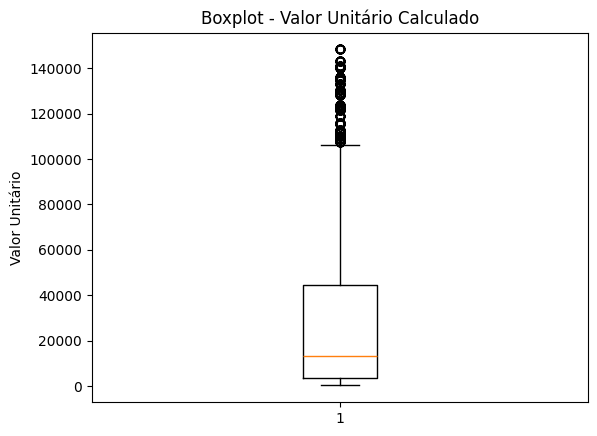

In [145]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(df_vendas["valor_unitario_calculado"])
plt.title("Boxplot - Valor Unitário Calculado")
plt.ylabel("Valor Unitário")

plt.show()

In [146]:
df_vendas.sort_values(
    by="valor_unitario_calculado",
    ascending=False
)[["id_produto", "valor_unitario_calculado"]].head(20)

,id_produto,valor_unitario_calculado
9602,76,148198.333333
9414,76,148198.333333
6029,76,148198.333333
9422,76,148198.333333
9442,76,148198.333333
5306,76,148198.285714
5058,76,148198.272727
598,76,148198.250000
4103,76,148198.250000
737,76,148198.250000


In [147]:
df_vendas.head()

,id_venda,id_cliente,id_produto,quantidade,valor_total,data_venda,valor_unitario_calculado
0,0,42,105,11,3405.0,2023-09-10,309.545455
1,1,3,136,9,16873.9,2024-09-15,1874.877778
2,2,25,139,7,9475.3,2024-08-13,1353.614286
3,4,20,23,5,55893.0,2023-02-03,11178.600000
4,5,8,57,4,451403.9,2024-02-12,112850.975000


In [148]:
df_vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 9895 entries, 0 to 9894
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   id_venda                  9895 non-null   int64         
 1   id_cliente                9895 non-null   int64         
 2   id_produto                9895 non-null   int64         
 3   quantidade                9895 non-null   int64         
 4   valor_total               9895 non-null   float64       
 5   data_venda                9895 non-null   datetime64[us]
 6   valor_unitario_calculado  9895 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(4)
memory usage: 541.3 KB


In [149]:
df_vendas.describe()

,id_venda,id_cliente,id_produto,quantidade,valor_total,data_venda,valor_unitario_calculado
count,9895.000000,9895.000000,9895.000000,9895.000000,9.895000e+03,9895,9895.000000
mean,5000.755533,24.874583,75.255786,8.015260,2.637978e+05,2023-12-30 18:04:45.962607,33072.043451
min,0.000000,1.000000,1.000000,1.000000,2.945000e+02,2023-01-01 00:00:00,294.025000
25%,2501.500000,13.000000,37.000000,4.000000,2.313820e+04,2023-06-30 00:00:00,3527.350000
50%,4999.000000,25.000000,74.000000,8.000000,8.222500e+04,2023-12-28 00:00:00,13264.222222
75%,7505.500000,37.000000,114.000000,12.000000,3.390945e+05,2024-07-02 00:00:00,44704.636364
max,9999.000000,49.000000,150.000000,15.000000,2.222973e+06,2024-12-31 00:00:00,148198.333333
std,2887.000000,14.177715,43.533397,4.301723,3.900072e+05,NaN,40204.480502


In [150]:
(df_vendas["valor_total"] / df_vendas["quantidade"]).round(2)

0          309.55
1         1874.88
2         1353.61
3        11178.60
4       112850.98
          ...    
9890      1424.83
9891      4071.02
9892      2638.15
9893    128568.25
9894     30833.50
Length: 9895, dtype: float64

In [151]:
(
    (df_vendas["valor_total"] / df_vendas["quantidade"]).round(2)
    == df_vendas["valor_unitario_calculado"].round(2)
).value_counts()

True    9895
Name: count, dtype: int64

Retirando coluna calculada.

In [152]:
df_vendas = df_vendas.drop(columns=["valor_unitario_calculado"])

Padronização dos tipos de colunas

In [153]:
df_vendas["id_venda"] = df_vendas["id_venda"].astype(int)
df_vendas["id_cliente"] = df_vendas["id_cliente"].astype(int)
df_vendas["id_produto"] = df_vendas["id_produto"].astype(int)
df_vendas["quantidade"] = df_vendas["quantidade"].astype(int)
df_vendas["valor_total"] = df_vendas["valor_total"].astype(float)
df_vendas["data_venda"] = pd.to_datetime(df_vendas["data_venda"])

In [154]:
df_vendas.head()

,id_venda,id_cliente,id_produto,quantidade,valor_total,data_venda
0,0,42,105,11,3405.0,2023-09-10
1,1,3,136,9,16873.9,2024-09-15
2,2,25,139,7,9475.3,2024-08-13
3,4,20,23,5,55893.0,2023-02-03
4,5,8,57,4,451403.9,2024-02-12


In [155]:
df_vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 9895 entries, 0 to 9894
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_venda     9895 non-null   int64         
 1   id_cliente   9895 non-null   int64         
 2   id_produto   9895 non-null   int64         
 3   quantidade   9895 non-null   int64         
 4   valor_total  9895 non-null   float64       
 5   data_venda   9895 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(4)
memory usage: 464.0 KB


Ordenar por data para o BI

In [156]:
df_vendas = df_vendas.sort_values("data_venda")
df_vendas

,id_venda,id_cliente,id_produto,quantidade,valor_total,data_venda
1215,1230,17,91,4,512566.80,2023-01-01
2276,2300,30,95,9,596858.40,2023-01-01
3098,3131,28,130,13,53873.00,2023-01-01
4170,4212,9,96,6,402538.75,2023-01-01
4251,4294,7,44,5,51332.30,2023-01-01
...,...,...,...,...,...,...
2993,3026,5,99,15,1528550.00,2024-12-31
3209,3242,36,83,2,269608.00,2024-12-31
2610,2638,2,9,6,226321.35,2024-12-31
8668,8762,48,33,13,87305.00,2024-12-31


Enviando para a Staging

In [157]:
df_vendas.to_csv(STAGING_PATH / "stg_vendas.csv", index=False)